# DFT-D4 dispersion, block by block: reproducing the reference `dftd4` with `xnn`

[DFT-D4 (Caldeweyher *et al.*, *J. Chem. Phys.* **150**, 154122, 2019)](https://doi.org/10.1063/1.5090222)
is the charge-dependent successor of the D3 London-dispersion correction: atomic
dynamic polarizabilities of tabulated reference systems are **scaled by atomic
partial charges** (eq 2, classical EEQ charges by default), **interpolated in the
coordination number** (eq 8), integrated to pairwise $C_6$ coefficients
(Casimir–Polder, eq 9), and summed with BJ damping (eqs 18–21) plus an
Axilrod–Teller–Muto three-body term (eqs 22–27).

In xnn this is `xnn.common.models.D4Dispersion`, a **model-agnostic add-on** (like
`LatentEwald` / `ForceStressOutput`): it stands alone as the model `"d4"` or wraps any
short-range model (`extra: {dispersion: {...}}`), and deploys through every channel
(PyTorch, TorchScript, ASE, LAMMPS). The implementation is an independent one written
from the paper; this notebook checks every block against the **reference
implementation** [`dftd4`](https://github.com/dftd4/dftd4) (v4.2.0, through its Python
package), the same protocol as the other fidelity notebooks.

**Reference code.** xnn does not copy, vendor, link or import any of `dftd4`'s code: the
package is used here purely as an external oracle whose numbers we compare against,
exactly as one would use a compiled reference program. The *reference data* of the
method (TD-DFT polarizabilities, reference CNs and charges, element constants) are
numerical values extracted from the published sources by `tools/build_d4_reference.py`.


## 0. Setup: `float64`, and `dftd4` *before* `torch`

The `dftd4` wheel bundles its own OpenMP runtime. If `torch` is imported first, the
two runtimes clash and `dftd4` returns **wrong EEQ charges** (silently: the water
molecule comes out with $q_\mathrm{O}\approx -0.009$ instead of $-0.586$). Importing
`dftd4` first avoids it (so does `torch.set_num_threads(1)`, which the test suite
uses); we assert the known water charges as a guard.


In [1]:
# dftd4 (the reference) must be imported before torch, see above
import numpy as np
from dftd4.interface import DampingParam, DispersionModel

import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import matplotlib.pyplot as plt
from ase.build import molecule, bulk

torch.set_default_dtype(torch.float64)

import xnn
from xnn.common.data import structure_to_graph, collate
from xnn.common.models import D4Dispersion, DFTD4, ForceStressOutput, c6_matrix
from xnn.common.models.d4 import BOHR, HARTREE, PBE0_D4

probe = DispersionModel(np.array([8, 1, 1]), molecule("H2O").positions / BOHR).get_properties()
assert abs(probe["partial charges"][0] + 0.58639069) < 1e-6, "dftd4/torch OpenMP clash: restart the kernel"
print("xnn:", xnn.__version__, "| dftd4 (reference) 4.2.0 | PBE0-D4 parameters:", PBE0_D4)


xnn: 0.2.1 | dftd4 (reference) 4.2.0 | PBE0-D4 parameters: {'s6': 1.0, 's8': 1.20065498, 'a1': 0.40085597, 'a2': 5.02928789, 's9': 1.0, 'alp': 16.0}


## Helpers

Both codes are driven in **atomic units**: positions in bohr go to `dftd4`, and xnn's
Angstrom/eV results are converted back with the same CODATA-2018 factors it uses
internally. `dftd4` reports the gradient $\partial E/\partial \mathbf r$ and the strain
derivative $\partial E/\partial\epsilon$ (its "virial"); xnn gives forces and the stress
$\sigma = V^{-1}\,\partial E/\partial\epsilon$.


In [2]:
def reference(atoms, charge=0.0, params=PBE0_D4, cutoffs=None):
    periodic = bool(atoms.pbc.any())
    model = DispersionModel(atoms.numbers, atoms.positions / BOHR, charge=charge,
                            lattice=atoms.cell[:] / BOHR if periodic else None,
                            periodic=np.array(atoms.pbc) if periodic else None)
    if cutoffs:
        model.set_realspace_cutoff(**cutoffs)
    res = model.get_dispersion(DampingParam(**params), grad=True)
    res.update(model.get_properties())
    return res

def xnn_d4(atoms, charge=0.0, model=None, **options):
    model = model or D4Dispersion(**options)
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers, "total_charge": charge}
    if atoms.pbc.any():
        s["cell"], s["pbc"] = atoms.cell[:], atoms.pbc
    graph = structure_to_graph(s, model.cutoff)
    out = ForceStressOutput(model, compute_stress=bool(atoms.pbc.any()))(graph)
    out = {k: v.detach() for k, v in out.items()}
    out["energy_au"] = float(out["energy"]) / HARTREE
    out["gradient_au"] = -out["forces"].numpy() / HARTREE * BOHR
    if atoms.pbc.any():
        out["virial_au"] = out["stress"][0].numpy() / HARTREE * BOHR**3 * (atoms.get_volume() / BOHR**3)
    out["c6"] = c6_matrix(out["dynamic_polarizabilities"]).numpy()
    return out

def report(name, atoms, charge=0.0, **options):
    ref, mine = reference(atoms, charge), xnn_d4(atoms, charge, **options)
    row = {"system": name, "N": len(atoms), "E [Eh]": ref["energy"],
           "|dE|": abs(mine["energy_au"] - ref["energy"]),
           "|dgrad|": np.abs(mine["gradient_au"] - ref["gradient"]).max(),
           "|dCN|": np.abs(mine["coordination_numbers"].numpy() - ref["coordination numbers"]).max(),
           "|dq|": np.abs(mine["eeq_charges"].numpy() - ref["partial charges"]).max(),
           "|dalpha|/alpha": np.abs(mine["polarizabilities"].numpy() / ref["polarizabilities"] - 1).max(),
           "|dC6|/C6": np.abs(mine["c6"] / ref["c6 coefficients"] - 1).max()}
    if atoms.pbc.any():
        row["|dvirial|"] = np.abs(mine["virial_au"] - ref["virial"]).max()
    return row

def show(rows):
    keys = list(rows[0])
    for extra in ("|dvirial|",):
        if any(extra in r for r in rows) and extra not in keys:
            keys.append(extra)
    print("".join(f"{k:>16s}" for k in keys))
    for r in rows:
        print("".join(f"{r.get(k, ''):>16.2e}" if isinstance(r.get(k, ''), float) else f"{str(r.get(k, '')):>16s}" for k in keys))


## Block 1: Coordination numbers and EEQ charges · eqs 6, 11–16

The D4 coordination number weights each error-function count by an
electronegativity factor (eq 6); the EEQ charges solve the constrained linear
system of eq 16 with the plain (electronegativity-free) CN of eq 14, softly capped at
8 in the reference code. `dftd4` exposes both through `get_properties()`.


In [3]:
rows = []
for name, charge in [("H2O", 0.0), ("CH3OH", 0.0), ("C6H6", 0.0), ("CH3CH2OH", 0.0), ("CO2", 0.0)]:
    rows.append(report(name, molecule(name), charge))
show(rows)

water = molecule("H2O")
ref, mine = reference(water), xnn_d4(water)
print("\nwater CN     dftd4:", ref["coordination numbers"], "\n             xnn  :", mine["coordination_numbers"].numpy())
print("water q      dftd4:", ref["partial charges"], "\n             xnn  :", mine["eeq_charges"].numpy())


          system               N          E [Eh]            |dE|         |dgrad|           |dCN|            |dq|  |dalpha|/alpha        |dC6|/C6
             H2O               3-0.0001576174317030107        5.42e-20        5.42e-20        0.00e+00        3.33e-16        2.22e-16        2.22e-16
           CH3OH               6-0.0012335328614920178        2.17e-19        1.29e-19        0.00e+00        3.75e-16        6.66e-16        1.55e-15
            C6H6              12-0.00898814444745347        3.47e-18        3.52e-19        4.44e-16        8.33e-17        6.66e-16        1.33e-15
        CH3CH2OH               9-0.0030075001576794188        4.34e-19        9.15e-20        4.44e-16        1.67e-16        6.66e-16        1.11e-15
             CO2               3-0.0007974225976500424        4.34e-19        1.02e-20        0.00e+00        1.67e-16        3.33e-16        9.99e-16



water CN     dftd4: [1.60884227 0.80442113 0.80442113] 
             xnn  : [1.60884227 0.80442113 0.80442113]
water q      dftd4: [-0.58639069  0.29319534  0.29319534] 
             xnn  : [-0.58639069  0.29319534  0.29319534]


## Block 2: Charge scaling, reference weighting and $C_6$ · eqs 2–9

The charge-dependence is the point of D4. Removing or adding an electron to the
ammonium/amide pair changes the EEQ charges, the scaled polarizabilities (eq 4) and
hence the $C_6$ coefficients; both codes agree for every total charge. The static
polarizabilities $\alpha(0)$ and the full $C_6$ matrix are compared element by element.


          system               N          E [Eh]            |dE|         |dgrad|           |dCN|            |dq|  |dalpha|/alpha        |dC6|/C6
             NH3               4-0.000336297649224461        5.42e-20        1.02e-19        0.00e+00        1.11e-16        0.00e+00        3.33e-16
     NH4+ (q=+1)               5-0.0003545463401048189        2.71e-19        8.13e-20        0.00e+00        8.88e-16        6.66e-16        1.11e-15
     NH4- (q=-1)               5-0.0013716042669924796        1.30e-18        8.67e-19        0.00e+00        8.88e-16        6.66e-16        1.33e-15
     NH3+ (q=+1)               4-0.0001816518458468447        2.71e-20        1.63e-20        0.00e+00        1.67e-16        0.00e+00        3.33e-16


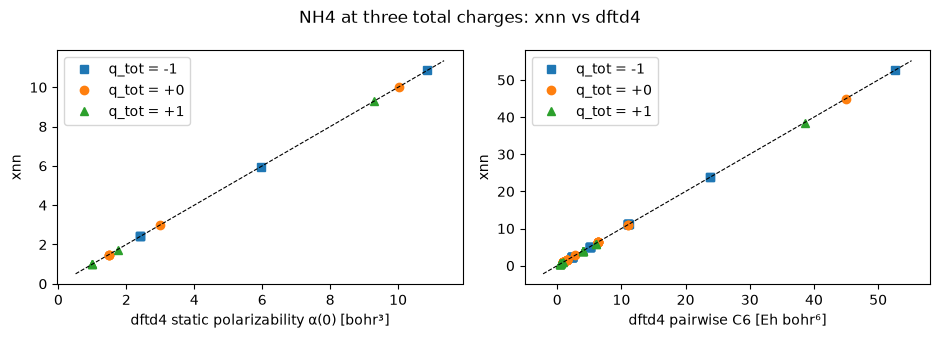

In [4]:
nh3 = molecule("NH3")
nh4 = nh3.copy(); nh4 += molecule("H"); nh4.positions[-1] = [0.0, 0.0, 1.5]
rows = [report("NH3", nh3, 0.0), report("NH4+ (q=+1)", nh4, 1.0), report("NH4- (q=-1)", nh4, -1.0),
        report("NH3+ (q=+1)", nh3, 1.0)]
show(rows)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
for q, style in [(-1.0, "s"), (0.0, "o"), (1.0, "^")]:
    ref, mine = reference(nh4, q), xnn_d4(nh4, q)
    ax[0].plot(ref["polarizabilities"], mine["polarizabilities"].numpy(), style, label=f"q_tot = {q:+.0f}")
    ax[1].plot(ref["c6 coefficients"].ravel(), mine["c6"].ravel(), style, label=f"q_tot = {q:+.0f}")
for a, lab in zip(ax, ["static polarizability α(0) [bohr³]", "pairwise C6 [Eh bohr⁶]"]):
    lim = a.get_xlim(); a.plot(lim, lim, "k--", lw=0.8); a.set_xlabel(f"dftd4 {lab}"); a.set_ylabel("xnn"); a.legend()
plt.suptitle("NH4 at three total charges: xnn vs dftd4"); plt.tight_layout(); plt.show()


## Block 3: Two-body (BJ) and three-body (ATM) energies · eqs 18–27

Energies, gradients and virials for molecules of increasing size. The ATM term uses
$C_6$ coefficients from *neutral* polarizabilities (paper sec II.C); `s9 = 0` switches it
off in both codes and must give identical two-body-only energies.


In [5]:
rows = [report(n, molecule(n)) for n in ("C2H6", "C6H6", "C60")]
show(rows)

c60 = molecule("C60")
two_body_ref = reference(c60, params={**PBE0_D4, "s9": 0.0})["energy"]
two_body_xnn = xnn_d4(c60, s9=0.0)["energy_au"]
full = xnn_d4(c60)
print(f"\nC60 two-body only:   dftd4 {two_body_ref:.12e}   xnn {two_body_xnn:.12e}   |diff| {abs(two_body_ref - two_body_xnn):.1e} Eh")
print(f"C60 ATM three-body: xnn E3 = {float(full['energy_3body']) / HARTREE:.6e} Eh  ({float(full['energy_3body']) / float(full['energy_2body']) * 100:+.2f} % of E2)")


          system               N          E [Eh]            |dE|         |dgrad|           |dCN|            |dq|  |dalpha|/alpha        |dC6|/C6
            C2H6               8-0.0021913693974552222        8.67e-19        6.78e-20        0.00e+00        1.11e-16        8.88e-16        1.33e-15
            C6H6              12-0.00898814444745347        3.47e-18        3.25e-19        4.44e-16        8.33e-17        6.66e-16        1.33e-15
             C60              60-0.1967102894599138        5.55e-17        7.05e-18        1.33e-15        2.03e-15        8.88e-16        2.00e-15



C60 two-body only:   dftd4 -2.042758827134e-01   xnn -2.042758827134e-01   |diff| 1.1e-16 Eh
C60 ATM three-body: xnn E3 = 7.565593e-03 Eh  (-3.70 % of E2)


## Block 4: Periodic systems · Ewald-summed EEQ

For a periodic cell the $1/r$ Coulomb matrix of the EEQ model is Ewald-summed. The
reference code chooses the splitting parameter automatically, sums fixed $\pm 2$
real- and reciprocal-space windows and averages over equivalent Wigner–Seitz images;
xnn follows the same conventions, so crystals agree to the same precision as
molecules -- energies, gradients **and** the strain derivative (virial), on
primitive cells, sheared cells and a small periodic water box.


In [6]:
nacl = bulk("NaCl", "rocksalt", a=5.64)
si = bulk("Si", "diamond", a=5.43)
sheared = si.copy(); c = sheared.cell[:].copy(); c[1, 0] += 0.5; sheared.set_cell(c, scale_atoms=False)
rng = np.random.default_rng(0)
box = molecule("H2O") * 1
from ase import Atoms
box = Atoms(cell=[6.2, 6.2, 6.2], pbc=True)
for _ in range(3):
    w = molecule("H2O"); w.rotate(rng.uniform(0, 360), rng.normal(size=3)); w.translate(rng.uniform(0, 6.2, 3)); box += w
rows = [report("NaCl rocksalt", nacl), report("Si diamond", si), report("Si sheared cell", sheared), report("water box (9 atoms)", box)]
show(rows)


          system               N          E [Eh]            |dE|         |dgrad|           |dCN|            |dq|  |dalpha|/alpha        |dC6|/C6       |dvirial|
   NaCl rocksalt               2-0.006890954411354103        2.90e-16        3.89e-19        1.15e-14        4.44e-16        2.22e-16        4.44e-16        5.12e-17
      Si diamond               2-0.023251471901675425        2.91e-16        8.73e-19        1.33e-15        0.00e+00        2.22e-16        4.44e-16        2.43e-16
 Si sheared cell               2-0.022196428758707833        3.47e-18        1.21e-17        8.88e-16        0.00e+00        4.44e-16        8.88e-16        4.52e-16
water box (9 atoms)               9-0.002941339168787877        0.00e+00        1.18e-18        2.22e-16        1.11e-15        1.55e-15        3.11e-15        1.54e-16


## Block 5: Matching non-default real-space cutoffs

The upstream defaults (60 / 40 / 30 bohr for pairs / triples / CN) are far longer
than an MLIP needs. Both codes accept shorter cutoffs; with the same values they
still agree exactly. xnn additionally offers quintic **switching windows** at the
cutoffs (`switch_width_pair`, `switch_width_triple`) so energy and forces stay
continuous in MD -- a deliberate extension, off by default.


cutoffs 12/9/10 bohr: dftd4 -8.814949146389e-03   xnn -8.814949146389e-03   |diff| 3.5e-18 Eh


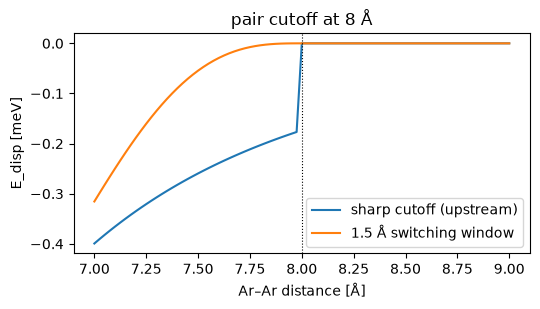

In [7]:
cluster = molecule("CH3CH2OH") + molecule("CH3CH2OH"); cluster.positions[9:] += [4.0, 0.5, 0.3]   # two ethanols
ref = reference(cluster, cutoffs=dict(disp2=12.0, disp3=9.0, cn=10.0))
mine = xnn_d4(cluster, cutoff_pair=12 * BOHR, cutoff_triple=9 * BOHR, cutoff_cn=10 * BOHR)
print(f"cutoffs 12/9/10 bohr: dftd4 {ref['energy']:.12e}   xnn {mine['energy_au']:.12e}   |diff| {abs(mine['energy_au'] - ref['energy']):.1e} Eh")

# smooth switching: a dimer scanned through the pair cutoff
d = np.linspace(7.0, 9.0, 81)
sharp = D4Dispersion(s9=0.0, cutoff_pair=8.0, cutoff_cn=8.0, cutoff_eeq_cn=8.0, cutoff_triple=8.0)
smooth = D4Dispersion(s9=0.0, cutoff_pair=8.0, switch_width_pair=1.5, cutoff_cn=8.0, cutoff_eeq_cn=8.0, cutoff_triple=8.0)
E = {m: [float(xnn_d4(Atoms("Ar2", positions=[[0, 0, 0], [x, 0, 0]]), model=mod)["energy"]) * 1e3 for x in d]
     for m, mod in [("sharp cutoff (upstream)", sharp), ("1.5 Å switching window", smooth)]}
plt.figure(figsize=(5.5, 3.2))
for k, v in E.items(): plt.plot(d, v, label=k)
plt.axvline(8.0, color="k", ls=":", lw=0.8); plt.xlabel("Ar–Ar distance [Å]"); plt.ylabel("E_disp [meV]"); plt.legend(); plt.title("pair cutoff at 8 Å"); plt.tight_layout(); plt.show()


### The one place the two codes differ: isolated atoms, at $10^{-9}$ e

An atom with no neighbor inside about two covalent radii has an EEQ coordination number
of exactly zero. Upstream evaluates the soft cap $\mathrm{CN}' = \ln(1+e^{8}) - \ln(1+e^{8-\mathrm{CN}})$
with the two logarithms coming out one ulp apart (they take different paths through the
Fortran runtime), leaving $1.8\\cdot10^{-15}$
instead of $0$; the EEQ right-hand side $\kappa\,\mathrm{CN}/\sqrt{\mathrm{CN} + 10^{-14}}$ then amplifies
that by $10^{7}$, so the charges of such systems differ by $\sim10^{-9}$ e and the energies by
$\sim10^{-13}$ hartree. xnn evaluates the cap exactly and gets zero. The effect is only
visible for genuinely isolated atoms (a stretched cluster, a line of far-apart atoms),
never inside a molecule or a solid, and it is well below any physical relevance.


In [8]:
line = Atoms(numbers=[1, 7, 6], positions=[[i * 12 * BOHR, 0.0, 0.0] for i in range(3)])   # three atoms 12 bohr apart
ref, mine = reference(line), xnn_d4(line)
print("isolated atoms:  dftd4 CN =", ref["coordination numbers"], " xnn CN =", mine["coordination_numbers"].numpy())
print("                 |dq| = %.1e e   |dE| = %.1e Eh" % (np.abs(mine["eeq_charges"].numpy() - ref["partial charges"]).max(),
                                                        abs(mine["energy_au"] - ref["energy"])))
import math
print("ln(1+e^8) in double: %.17g;  one ulp at this magnitude is %.1e, the residual upstream's cap leaves for CN = 0" % (math.log(1 + math.exp(8.0)), np.spacing(8.0)))


isolated atoms:  dftd4 CN = [0. 0. 0.]  xnn CN = [0. 0. 0.]
                 |dq| = 1.4e-09 e   |dE| = 2.7e-15 Eh
ln(1+e^8) in double: 8.000335406372896;  one ulp at this magnitude is 1.8e-15, the residual upstream's cap leaves for CN = 0


## Block 6: One implementation, every channel

The same `DFTD4` module serves the batched `AtomicGraph` path (training), the
scripted whole-system and pair-style ABIs (`TorchScriptPotential`, LAMMPS) and the
ASE calculator; and it wraps a short-range model without touching that model's own
neighborhood (the core sees only the edges within its cutoff).


In [9]:
from xnn.common.config import from_dict
from xnn.common.data import build_neighbor_list
from xnn.common.deploy import TorchScriptPotential, XNNCalculator
from xnn.common.models import build_model

atoms = molecule("C6H6")
d4 = D4Dispersion(cutoff_pair=12.0, cutoff_triple=9.0, cutoff_cn=10.0, cutoff_eeq_cn=10.0)
eager = xnn_d4(atoms, model=d4)
scripted = torch.jit.script(TorchScriptPotential(d4, d4.cutoff).eval())
ts = scripted(torch.tensor(atoms.positions), torch.tensor(atoms.numbers))
ei, cs = build_neighbor_list(torch.tensor(atoms.positions), d4.cutoff)
ts_pair = scripted.forward_lammps(torch.tensor(atoms.positions), ei, cs, torch.tensor(atoms.numbers), torch.zeros(3, 3))
atoms.calc = XNNCalculator(ForceStressOutput(d4), cutoff=d4.cutoff)
print(f"eager           {float(eager['energy']):.15f} eV")
print(f"TorchScript     {float(ts['energy']):.15f} eV   |dF| = {float((ts['forces'] - eager['forces']).abs().max()):.1e}")
print(f"pair-style ABI  {float(ts_pair['energy']):.15f} eV")
print(f"ASE calculator  {atoms.get_potential_energy():.15f} eV")

# batching: a batch of three molecules equals the three single evaluations
graphs = [structure_to_graph({"pos": molecule(n).positions, "atomic_numbers": molecule(n).numbers}, d4.cutoff) for n in ("H2O", "CH4", "C6H6")]
e_batch = d4(collate(graphs))["energy"]
e_single = torch.stack([d4(g)["energy"][0] for g in graphs])
print("batch vs single |dE| =", float((e_batch - e_single).abs().max()))

# wrapping a short-range model: (untrained) MACE + D4, the core keeps its 4.5 Å neighborhood
cfg = from_dict({"model": {"name": "mace", "cutoff": 4.5, "n_interactions": 1, "n_rbf": 6, "n_features": 8,
                           "extra": {"species": [1, 6], "l_max": 2,
                                     "dispersion": {"cutoff_pair": 12.0, "cutoff_triple": 9.0, "cutoff_cn": 10.0, "cutoff_eeq_cn": 10.0}}}})
torch.manual_seed(0)
wrapped = build_model(cfg.model)
out = wrapped(structure_to_graph({"pos": atoms.positions, "atomic_numbers": atoms.numbers}, wrapped.cutoff))
core = wrapped.model(structure_to_graph({"pos": atoms.positions, "atomic_numbers": atoms.numbers}, 4.5))
print(f"MACE+D4: cutoff {wrapped.cutoff} Å, E = E_sr + E_disp: {float(out['energy']):.6f} = {float(core['energy']):.6f} + {float(out['energy_disp']):.6f}  (|E_sr - MACE alone| = {abs(float(out['energy_sr']) - float(core['energy'])):.1e})")


eager           -0.244579870193917 eV
TorchScript     -0.244579870193917 eV   |dF| = 0.0e+00
pair-style ABI  -0.244579870193917 eV
ASE calculator  -0.244579870193917 eV
batch vs single |dE| = 0.0


MACE+D4: cutoff 12.0 Å, E = E_sr + E_disp: 6.332386 = 6.576966 + -0.244580  (|E_sr - MACE alone| = 0.0e+00)


## Summary

| block | quantity | xnn vs `dftd4` |
|---|---|---|
| 1 | D4 and EEQ coordination numbers, EEQ charges | ~1e-13 |
| 2 | charge-scaled polarizabilities, $C_6$ matrix (any total charge) | ~1e-12 relative |
| 3 | two-body + ATM energies, gradients (molecules up to C60) | ~1e-15 Eh, ~1e-14 Eh/bohr |
| 4 | periodic energies, gradients, virials (Ewald EEQ) | ~1e-15 Eh, ~1e-13 |
| 5 | shorter, matching real-space cutoffs | ~1e-16 Eh |
| 5 | isolated atoms (upstream's rounded CN cap) | 1e-9 e in q, 1e-13 Eh (documented) |
| 6 | eager / TorchScript / pair-style / ASE / batch | identical |

Unit conversions matter at this level: `dftd4` derives the bohr radius from the
CODATA-2018 constants ($a_0 = \hbar / m_e c \alpha$), which differs from the tabulated
0.529177210903 Å in the 12th digit; xnn uses the same derived value so the covalent
radii, and with them the coordination numbers, agree to round-off.
